# Portfolio Metrics

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import contextlib
import io
from copulae import GaussianCopula, StudentCopula
from scipy.stats import t as student_t, norm, laplace, genextreme
from pandas_datareader import data as pdr
import statsmodels.api as sm

In [2]:
q = {
    "VEA":43, 
    "META":2, 
    "MSFT":3, 
    "JPM":4, 
    "SPY":42
}

tickers = list(q.keys())

years = 10
end_date = date.today()
start_date = end_date - timedelta(days=years * 365)

In [3]:
def get_data(symbols, start_date, end_date, interval="1d"):
    """
    Fetch OHLCV data from Yahoo Finance using yfinance.

    Returns:
        data: long DataFrame with columns:
              symbol, open, high, low, close, adj_close, volume
        close_prices: wide DataFrame of close prices by symbol
    """

    raw = yf.download(
        tickers=symbols,
        start=start_date.isoformat(),
        end=end_date.isoformat(),
        interval=interval,
        auto_adjust=False,
        group_by="ticker",
        progress=True,
        threads=True
    )

    all_dfs = []

    for symbol in symbols:
        try:
            df = raw[symbol].copy()
        except KeyError:
            print(f"No data returned for {symbol}")
            continue

        if df.empty:
            print(f"No data returned for {symbol}")
            continue

        df = df.rename(columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume"
        })

        df["symbol"] = symbol
        df.index.name = "timestamp"

        df = df[["symbol", "open", "high", "low", "close", "adj_close", "volume"]]
        all_dfs.append(df)

    data = pd.concat(all_dfs).sort_index()

    close_prices = data.pivot_table(
        values="close",
        index=data.index,
        columns="symbol"
    )

    return data, close_prices


In [4]:
data, close_prices = get_data(tickers, start_date, end_date, interval="1mo")

print(close_prices.tail())

[*********************100%***********************]  5 of 5 completed

symbol             JPM        META        MSFT         SPY        VEA
timestamp                                                            
2026-03-01  294.160004  572.130005  370.170013  650.340027  64.080002
2026-04-01  313.230011  611.909973  407.779999  718.659973  68.800003
2026-05-01  299.309998  632.510010  450.239990  756.479980  71.769997
2026-06-01  327.329987  563.289978  373.019989  746.770020  71.250000
2026-07-01  341.100006  646.010010  393.820007  743.289978  69.699997


## Testing out the `Portfolio` class 

In [5]:
from portfolio import Portfolio

In [6]:
# weights of each holding
w = {k: v/sum(q.values()) for k, v in q.items()}

# tickers and price data
my_pft = list(w.keys())
my_prices = close_prices[my_pft]


# create instance of Portfolio class
p = Portfolio(tickers=my_pft, df=my_prices, weights=w, interval="1mo")

In [7]:
macro = p.macro_data()

In [28]:
import os
os.getcwd()

'/Users/antoniomelacini/Desktop/Code-Projects/portfolio-metrics'

In [ ]:
# save data to CSVs for analyzing in R
macro.to_csv('')
w = p.weights
portfolio_returns = p.returns(log=False).dot(
    np.array([w[t] for t in p.data.columns])
)
portfolio_returns.to_csv('/Users/antoniomelacini/Desktop/Code-Projects/portfolio-metrics/macro.csv')

FileNotFoundError: [Errno 2] No such file or directory: ''

In [8]:
my_pft

['VEA', 'META', 'MSFT', 'JPM', 'SPY']

In [9]:
w

{'VEA': 0.4574468085106383,
 'META': 0.02127659574468085,
 'MSFT': 0.031914893617021274,
 'JPM': 0.0425531914893617,
 'SPY': 0.44680851063829785}

In [10]:
summary = p.uni_summary()
summary

,Portfolio,VEA,META,MSFT,JPM,SPY
Mean (Annual),0.116094,0.076391,0.230646,0.218546,0.193019,0.136643
Volatility (Annual),0.151465,0.156849,0.359103,0.215745,0.240093,0.155386
Sharpe (Annual),0.436362,0.168256,0.503049,0.781225,0.595682,0.557600
Sortino (Annual),0.665240,0.248663,0.816000,1.381303,1.005556,0.884324
Skew (1mo),-0.540052,-0.382858,-0.175865,-0.102344,-0.140281,-0.435718
Excess Kurtosis (1mo),1.106449,1.399183,1.139554,0.133216,0.937629,0.685663
5.0% VaR (1mo),-0.075667,-0.068738,-0.118933,-0.076215,-0.087347,-0.070110
5.0% ES (1mo),-0.096711,-0.101719,-0.207510,-0.110371,-0.138864,-0.095472
Max Drawdown,-0.280249,-0.306900,-0.754441,-0.309794,-0.384896,-0.247979


#### Need to adapt uni_summary() method to..
- show portfolio sample stats as well (and hence change name from uni_summary() to just summary or something)

### Other next steps:
- use OLS to estimate market beta and/or industry betas

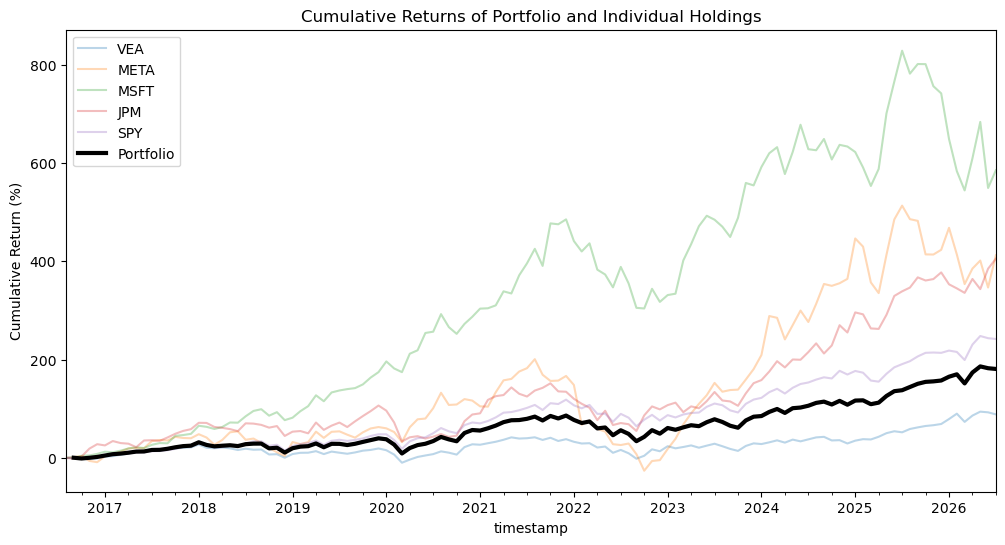

In [11]:
cum_rets = p.data.apply(lambda x: 100*(x/x.iloc[0]-1))

w = p.weights
portfolio_returns = p.returns(log=False).dot(
    np.array([w[t] for t in p.data.columns])
)

portfolio_cumulative = ((1 + portfolio_returns).cumprod() - 1) * 100

ax = cum_rets.plot(
    title="Cumulative Returns of Portfolio and Individual Holdings",
    xlabel="Date",
    ylabel="Cumulative Return (%)",
    alpha=0.3,
    figsize=(12, 6),
    legend=True
)

portfolio_cumulative.plot(
    ax=ax,
    linewidth=3,
    color="black",
    label="Portfolio"
)

plt.legend()
plt.show()

## CAPM and Macroeconomic Regressions for Risk Attribution

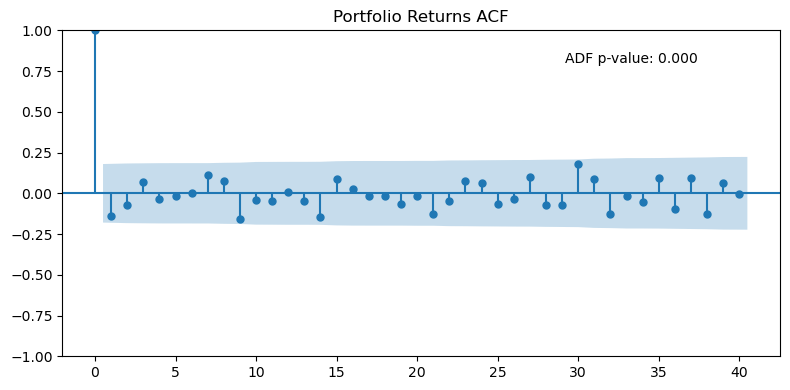

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Calculate portfolio returns using weights aligned with the return columns
returns = p.returns(log=False).dropna()
weights = pd.Series(p.weights).reindex(returns.columns)
portfolio_returns = returns.dot(weights)

# Run the Augmented Dickey-Fuller test on the one-dimensional portfolio series
adf_statistic, adf_pvalue, *_ = adfuller(portfolio_returns)

fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(portfolio_returns, lags=40, ax=ax)
ax.set_title('Portfolio Returns ACF')
ax.text(0.7, 0.9, f"ADF p-value: {adf_pvalue:.3f}", transform=ax.transAxes)

plt.tight_layout()
plt.show()

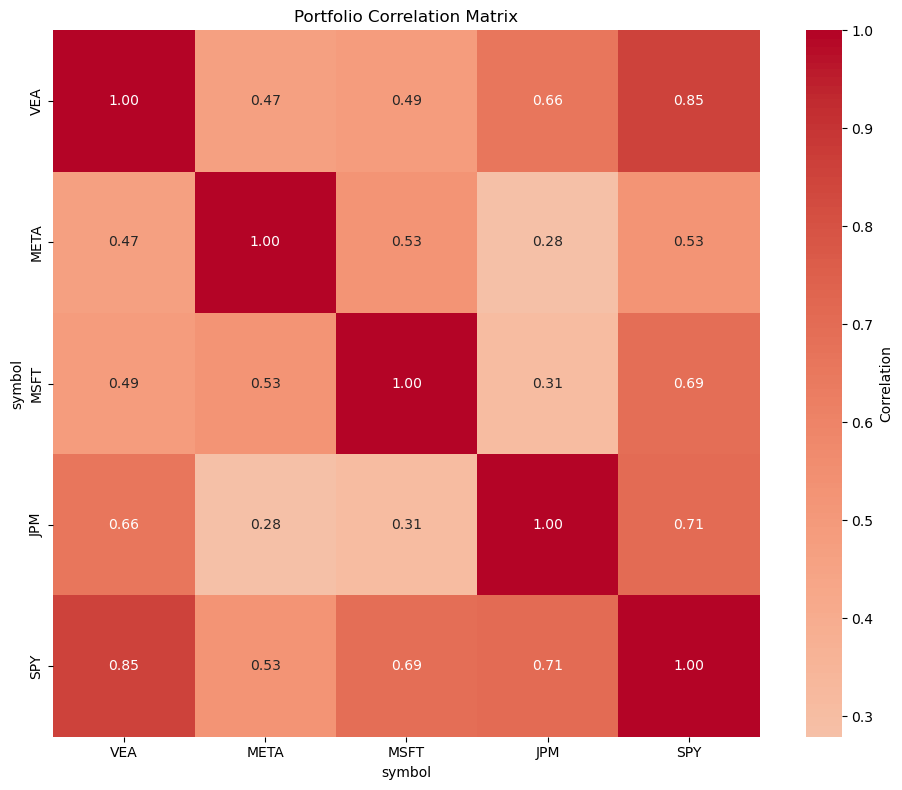

In [ ]:
corr_matrix = p.dependence()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Portfolio Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
fit = p.copula_fit(criterion="aic") # note: this can take a couple minutes for the student-t copula

In [ ]:
fit["summary"]

,family,loglik,n_params,aic,bic,params,error
0,student_t,183.861663,11,-345.723326,-315.152967,"{'df': 6.069956000849269, 'rho': [0.5257332283...",None
1,gaussian,175.190315,10,-330.380629,-302.589394,"{'rho': [0.5297915743693314, 0.499510131865033...",None


In [ ]:
margins = p.margin_fit()

From Sklar's theorem, for a random $d$-vector $X=(X_1,\dots,X_d)^\top$ with joint CDF $F$, copula $C$, and margins $F_i$ for $X_i$, the CDF can be decomposed into
$$
F(x) = C\Big(F_1(x_1),\dots,F_d(x_d) \Big) \quad \forall x\in\mathbb{R}^d
$$
and hence the density $f$ satisfies
$$
f(x) = {\small \frac{d}{dx}} F(x) =  c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) \quad \forall x\in\mathbb{R}^d
$$
where $c$ is the density of the copula, i.e., 
$$ 
c(u) = {\small \frac{\partial^d}{\partial u_1 \cdots \partial u_d }} C(u)
$$

The $t$ copula with $\nu>0$ degrees of freedom and correlation matrix $P\in\mathbb{R}^{d\times d}$ can be represented by
$$
C^t_{\nu, P}(u) = \int_{-\infty}^{t^{-1}_\nu(u_1)} \cdots \int_{-\infty}^{t^{-1}_\nu(u_d)} \frac{\Gamma(\frac{\nu + d}{2})}{\Gamma(\nu/2) \sqrt{(\pi\nu)^d \det P}} 
\Big(1 + \frac{1}{\nu} x^\top P^{-1} x \Big)^{-(\nu + d)/{2}} dx \quad\quad \forall u\in(0,1)^d
$$
where $t^{-1}_\nu$ is the quantile function of a univariate $t_{(\nu)}$ distribution. 

Source: ("The $t$ Copula and Related Copulas") https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/303eb11b4d617b79c1257b0800744575/$FILE/t%20copula%20demarta%20mcneil.pdf

Let $R=w^\top X$ be the portfolio return random variable, where $w\in[0,1]^d$ is the vector of (fixed) portfolio weights.

The CDF is of $R$ is then 
$$
\begin{aligned}
G(r) &= \mathbb{P}(R\leq r) = \int_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x)dx = \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x) dx \\
&= \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) dx
\end{aligned}
$$


In [ ]:
simulate = p.joint_simulator()

Let $F_R$ be the CDF of the continuous random variable $R$.
$$
\text{VaR}_\alpha(R) = F_R^{-1}(\alpha)
$$
$$
\text{ES}_\alpha(R)=\mathbb{E}[R\mid R \leq \text{VaR}_\alpha(R)]
$$

Monte Carlo estimate of ES(1.00%) is -13.11% with 95% CI: (-13.1106%, -13.1104%)
Standard Error of ES estimate: 0.000030%


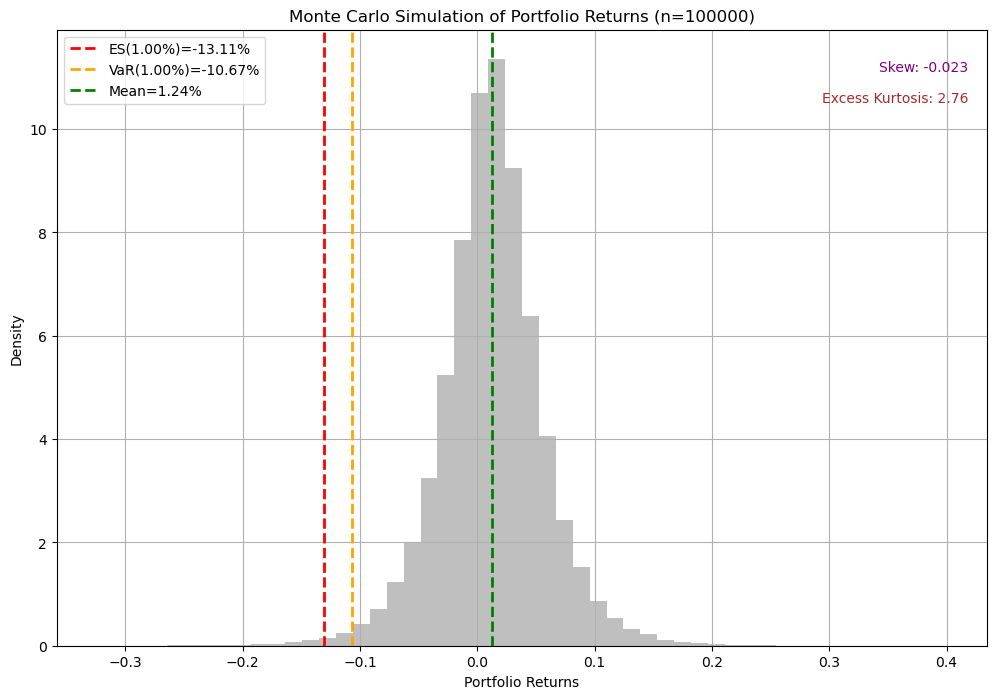

In [ ]:
monte_carlo_es = p.monte_carlo_ES(n_samples=int(1e5), alpha=0.01)

### `SimReturnsVector()`
1. Simulate $V\sim C$ via $V_i=C^{-1}(U_i)$ for $i=1,\dots,d$ where $U\overset{iid}{\sim}\text{Unif}(0,1)$
2. Simulate and return $X\sim F$ via $X_i=F_i^{-1}(V_i)$ for $i=1,\dots,d$

### `SimPortfolioReturn()`
1. Simulate $X=$`SimReturnsVector()`
2. Return $R=w^\top X$

### `SimShortfall()`
1. Simulate $R=$`SimPortfolioReturn()`
2. If $R\leq \text{VaR}_\alpha(R)$, (accept the sample) return $R$. Otherwise, return None (skip to next sample)

## Next Features for this Project

- "Flip Negative Correlations" switch toggle on the web app which turns negative corr's positive
    - this enhances the dependence stress testing tool.
    - can also include reference correlation increase figure for how much they increased in historical crises (e.g. GFC, great depression, 2020)

- final cleanup for this iteration:
    - re-format/organize tables for fitted copula and margins to only show relevant columns (i.e. the 'best' models)
    - figure out why portfolio column in uni_summary() output is None for tickers=['SPY', 'SPCX'], interval='1d' (and dates are month-to-date), and weights=[0.5, -0.5]

AFTER FINISHING MIT FACTOR MODELING STUDYING:
- linear factor models
    - understanding portfolio risks/drivers
    - parameter reduction for covariance estimation
    - stress testing (e.g. VaR / ES under different macro shock/equity market scenarios)
- do the same as above but with *neural nets* instead of linear factor model
- portfolio optimization
    - Mean-Var optimiziation (with different covariance matrix estimates incl. the factor model est.)
    - Mean-ES optimization
- volatility models
    - GARCH (+ dynamic mean return model -- look for examples online of what ppl use / look at Mike M's PhD paper)
    - Stochastic Vol model (Heston) - which also models returns as a whole
    - VaR / ES forecasting from the model
- genAI feature(s): 
    - RAG over market news for explaining recent portfolio movements

SEPARATE PROJECT:
- market bubble / market crash predictor
    - can try a variety of methods and/or an ensemble of them
        - the graph theory one or whatever from algebraic continuation channel,
        - the XLU/SPY z-score thiing or whatever from iPhone notes on PROJECTS

### Next: do ES-based portfolio optimization (e.g. using `cvxpy`) and test out/make portfolio-wide summaries

- Review portfolio optimization math
    - CS 335 chapter 
    - ACTSC 372 chapter 
    - CO 372

Need to use weights not quantities. Also, we have to make an assumption about dynamic rebalancing right?

### Some Plotting (make this a method)

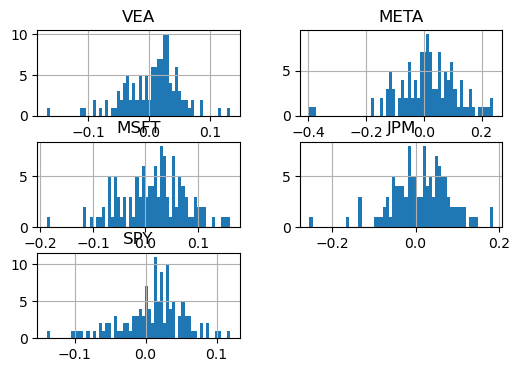

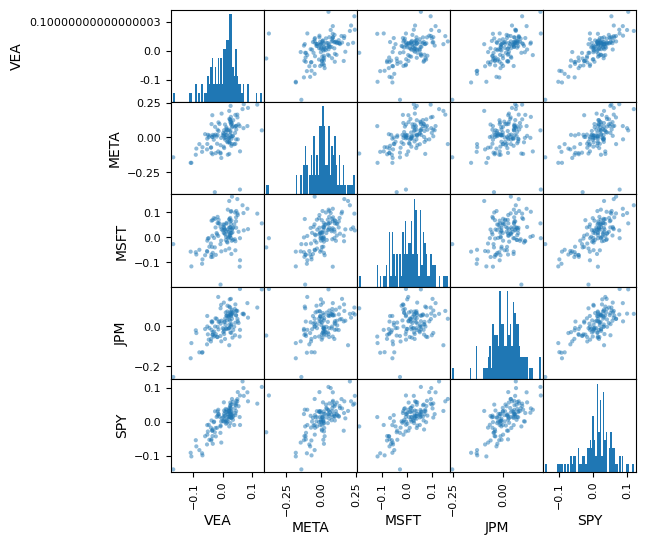

In [ ]:
# histogram of returns of each holding
log_returns = p.returns(log=True)
log_returns.hist(bins=60, figsize=(6,4))
plt.show()

# scatterplot matrix of portfolio returns
pd.plotting.scatter_matrix(log_returns, figsize=(6,6), hist_kwds={'bins':60})
plt.show()

### Another Project: make+test index arbitrage strategy taking advantage of strong correlation between VEA and SPY (and likely many common holdings)